THƯ VIỆN

In [1]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import pickle
import warnings
import streamlit as st
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error
from sqlalchemy import create_engine
from collections import Counter
from sklearn.utils import resample
warnings.filterwarnings('ignore')
pio.renderers.default = "browser"
random.seed(42)
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor


HUYỀN

KẾT NỐI SQL

In [2]:

SERVER_NAME = 'LAPTOP-BPDB2BM4\\SQLEXPRESS' # Hoặc 'DESKTOP-06I4T19\SQLEXPRESS'
DATABASE_NAME = 'CarProject'
DRIVER_NAME = 'ODBC Driver 17 for SQL Server'
connection_url = f"mssql+pyodbc://@{SERVER_NAME}/{DATABASE_NAME}?driver={DRIVER_NAME.replace(' ', '+')}&trusted_connection=yes"
engine = create_engine(connection_url)

print("✅ Đồ nghề và kết nối SQL đã sẵn sàng!")

✅ Đồ nghề và kết nối SQL đã sẵn sàng!


ĐƯA DỮ LIỆU VÀO SQL

In [3]:
# 1. Đọc file CSV gốc
df_raw = pd.read_csv('car_price_prediction.csv')

# 2. Đẩy thẳng toàn bộ vào SQL Server thành một bảng tên là 'Cars_Raw'
df_raw.to_sql('Cars_Raw', con=engine, if_exists='replace', index=False)

print("✅ Đã nhập kho dữ liệu thô vào bảng 'Cars_Raw' trong SQL Server.")

✅ Đã nhập kho dữ liệu thô vào bảng 'Cars_Raw' trong SQL Server.


CHỌN FEATURE

In [4]:

sql_query = """
SELECT 
    ID,Price, Levy, Manufacturer, Model, [Prod. year], Category, 
    [Fuel type], [Engine volume], Mileage, [Leather interior],
    Cylinders, [Gear box type], [Drive wheels], 
    Color, Airbags
FROM Cars_Raw
ORDER BY ID

"""

# Thực thi SQL và kéo dữ liệu sạch (đã lọc đáy) về Pandas
df = pd.read_sql_query(sql_query, con=engine)

print(f"✅ Đã dùng truy vấn SQL rút {df.shape[1]} ")
df.head(3)

✅ Đã dùng truy vấn SQL rút 16 


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Fuel type,Engine volume,Mileage,Leather interior,Cylinders,Gear box type,Drive wheels,Color,Airbags
0,20746880,157,-,MERCEDES-BENZ,S 500,1939,Limousine,Petrol,2.4,126000 km,Yes,4.0,Automatic,Rear,White,0
1,23242980,200,-,TOYOTA,Land Cruiser Prado,2017,Jeep,Petrol,2.7,95000 km,Yes,4.0,Automatic,4x4,Black,10
2,24367759,85702,-,MERCEDES-BENZ,Sprinter 516,2013,Microbus,Diesel,2.2 Turbo,225000 km,Yes,6.0,Manual,Rear,White,4


XỬ LÍ DỮ LIỆU

In [5]:
# Xử lý cột Mileage (xóa ' km') và điền ô trống bằng Median
df['Mileage'] = df['Mileage'].astype(str).str.replace(' km', '')
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')
df['Mileage'].fillna(df['Mileage'].median(), inplace=True)

# Hierarchical Imputation cho cột Levy (Thuế/Phí)
df['Levy'] = pd.to_numeric(df['Levy'], errors='coerce')

# Lớp lưới 1: Nội suy chính xác theo Hãng + Năm + Động cơ + Loại Nhiên liệu
df['Levy'] = df['Levy'].fillna(
    df.groupby(['Manufacturer', 'Prod. year', 'Engine volume', 'Fuel type'])['Levy'].transform('median')
)

# Lớp lưới 2: Nới lỏng - Lấy theo Hãng + Năm sản xuất
df['Levy'] = df['Levy'].fillna(
    df.groupby(['Manufacturer', 'Prod. year'])['Levy'].transform('median')
)

# Lớp lưới 3: Nới lỏng - Lấy theo Phân khúc xe (Category)
df['Levy'] = df['Levy'].fillna(
    df.groupby('Category')['Levy'].transform('median')
)

# Lớp lưới 4: Lưới an toàn cuối cùng - Median toàn cục
df['Levy'] = df['Levy'].fillna(df['Levy'].median())

# === TRÍCH XUẤT TURBO & TUỔI XE TRƯỚC KHI LỌC OUTLIER ===
# 1. Tạo cột 'is_Turbo' và làm sạch cột 'Engine volume'
df['is_Turbo'] = df['Engine volume'].astype(str).str.contains('Turbo', case=False).astype(int)
df['Engine volume'] = df['Engine volume'].astype(str).str.replace(' Turbo', '', case=False).str.strip()
df['Engine volume'] = pd.to_numeric(df['Engine volume'], errors='coerce')

# 2. Chuyển năm sản xuất thành tuổi xe
df['Car_Age'] = 2024 - df['Prod. year']
df.drop('Prod. year', axis=1, inplace=True) # Xóa cột cũ

print("✅ Đã xử lý Missing Values, Levy, is_Turbo và Car_Age!")


✅ Đã xử lý Missing Values, Levy, is_Turbo và Car_Age!


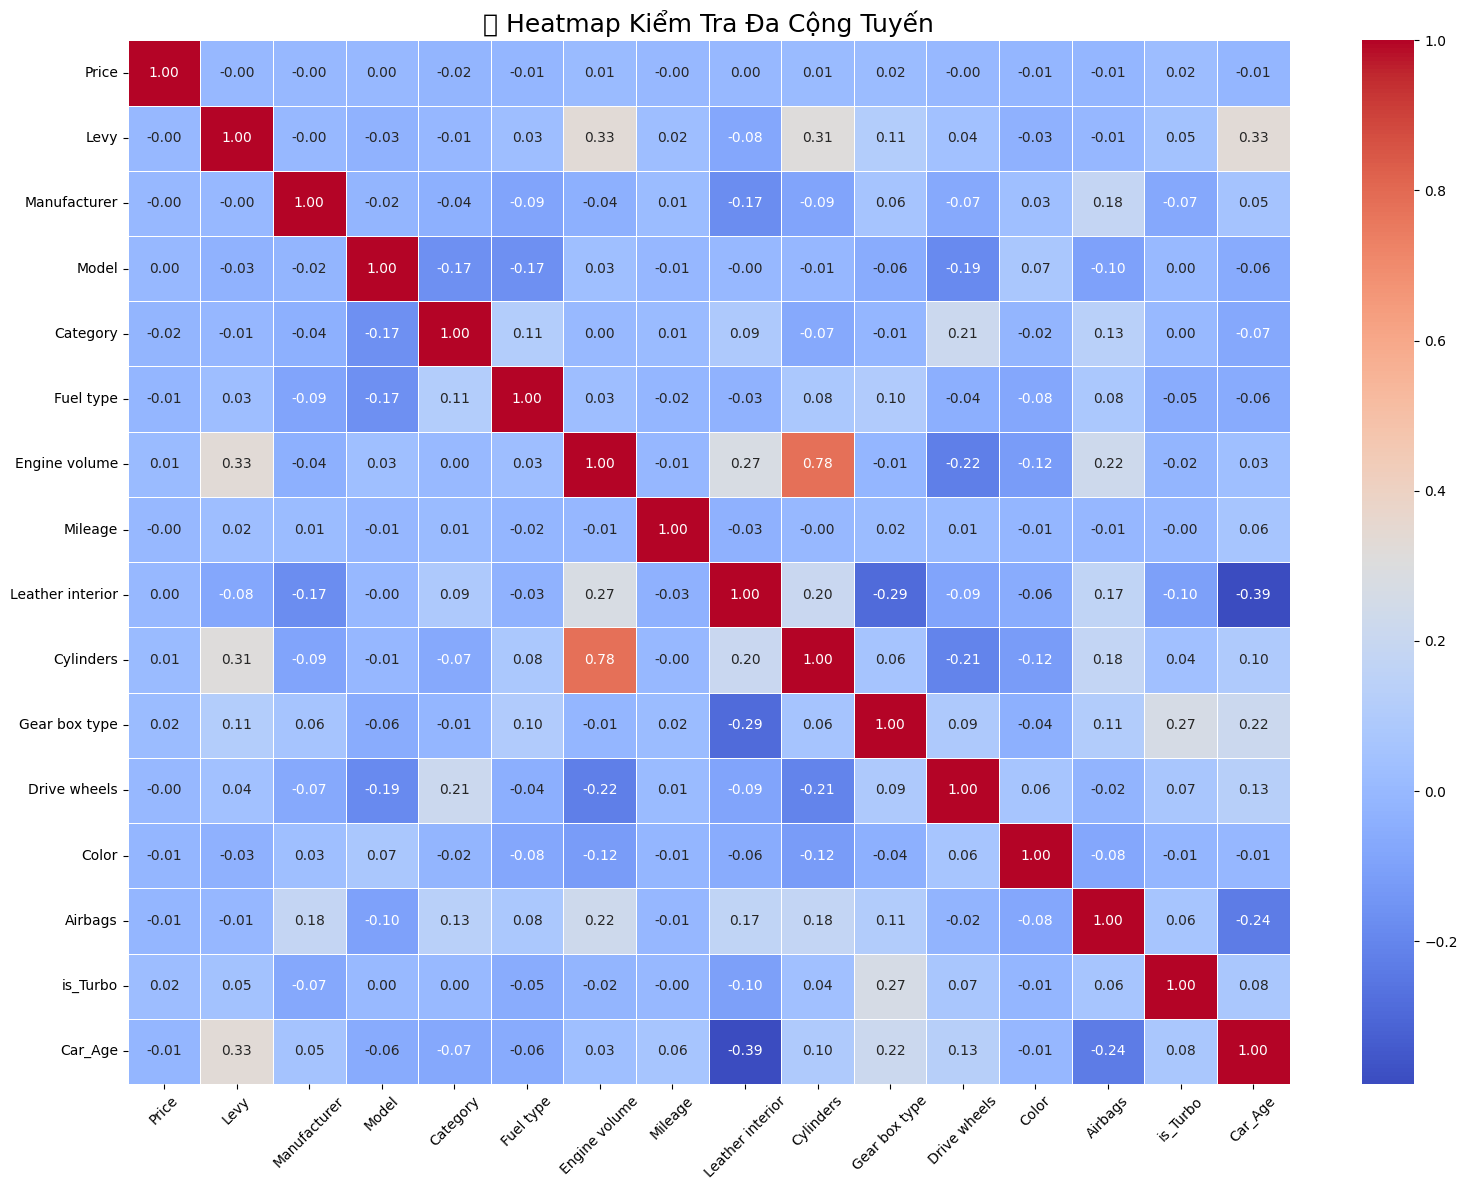

In [6]:
# ==========================================
# HEATMAP KIỂM TRA ĐA CỘNG TUYẾN
# Đặt cell này SAU CELL "XỬ LÍ DỮ LIỆU"
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Copy dữ liệu sau xử lí
heatmap_df = df.copy()

# -----------------------------------
# Encode tạm các cột text thành số
# để tính correlation
# -----------------------------------
cat_cols = [
    'Manufacturer', 'Model', 'Category',
    'Fuel type', 'Leather interior',
    'Gear box type', 'Drive wheels',
    'Color'
]

for col in cat_cols:
    heatmap_df[col] = heatmap_df[col].astype('category').cat.codes

# -----------------------------------
# Chọn toàn bộ feature hiện có
# -----------------------------------
feature_cols = [
    'Price',
    'Levy',
    'Manufacturer',
    'Model',
    'Category',
    'Fuel type',
    'Engine volume',
    'Mileage',
    'Leather interior',
    'Cylinders',
    'Gear box type',
    'Drive wheels',
    'Color',
    'Airbags',
    'is_Turbo',
    'Car_Age'
]

# Tính ma trận tương quan
corr_matrix = heatmap_df[feature_cols].corr()

# -----------------------------------
# VẼ HEATMAP
# -----------------------------------
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("🔥 Heatmap Kiểm Tra Đa Cộng Tuyến", fontsize=18)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

HIẾU

📊 THỐNG KÊ PRICE & MILEAGE
💰 Price:
   Min : 1 $
   Max : 26,307,500 $

🚗 Mileage:
   Min : 0 km
   Max : 2,147,483,647 km


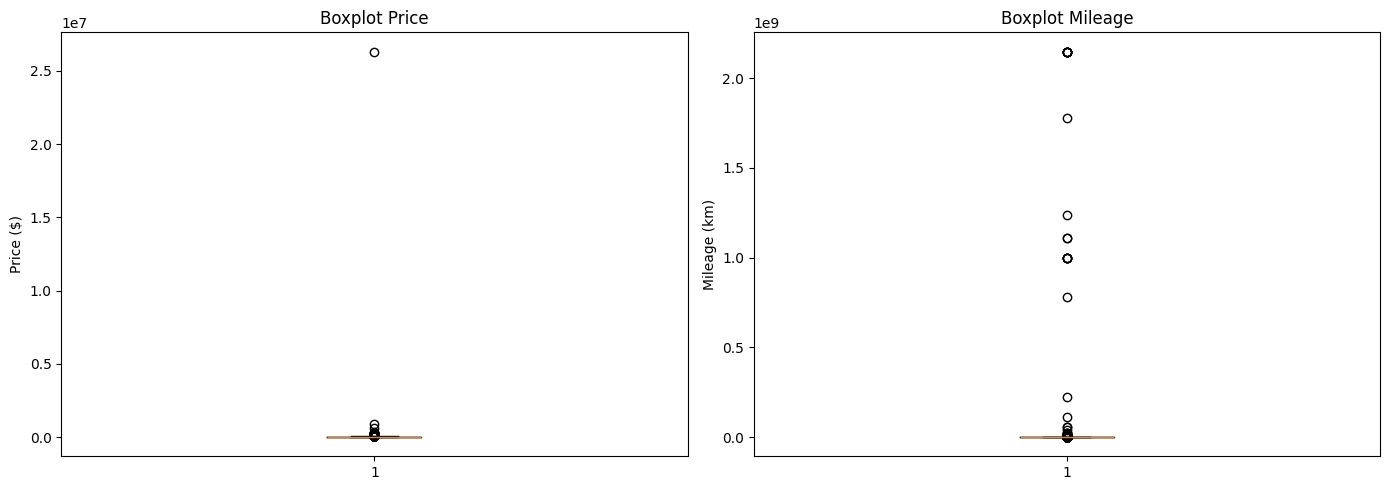

In [7]:
# ==========================================
# KIỂM TRA OUTLIER PRICE & MILEAGE
# ==========================================

import matplotlib.pyplot as plt

# In min/max
print("📊 THỐNG KÊ PRICE & MILEAGE")
print("=" * 45)

print(f"💰 Price:")
print(f"   Min : {df['Price'].min():,.0f} $")
print(f"   Max : {df['Price'].max():,.0f} $")

print(f"\n🚗 Mileage:")
print(f"   Min : {df['Mileage'].min():,.0f} km")
print(f"   Max : {df['Mileage'].max():,.0f} km")

# ==========================================
# VẼ BOXPLOT KIỂM TRA OUTLIER
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Price
axes[0].boxplot(df['Price'], vert=True)
axes[0].set_title('Boxplot Price')
axes[0].set_ylabel('Price ($)')

# Boxplot Mileage
axes[1].boxplot(df['Mileage'], vert=True)
axes[1].set_title('Boxplot Mileage')
axes[1].set_ylabel('Mileage (km)')

plt.tight_layout()
plt.show()

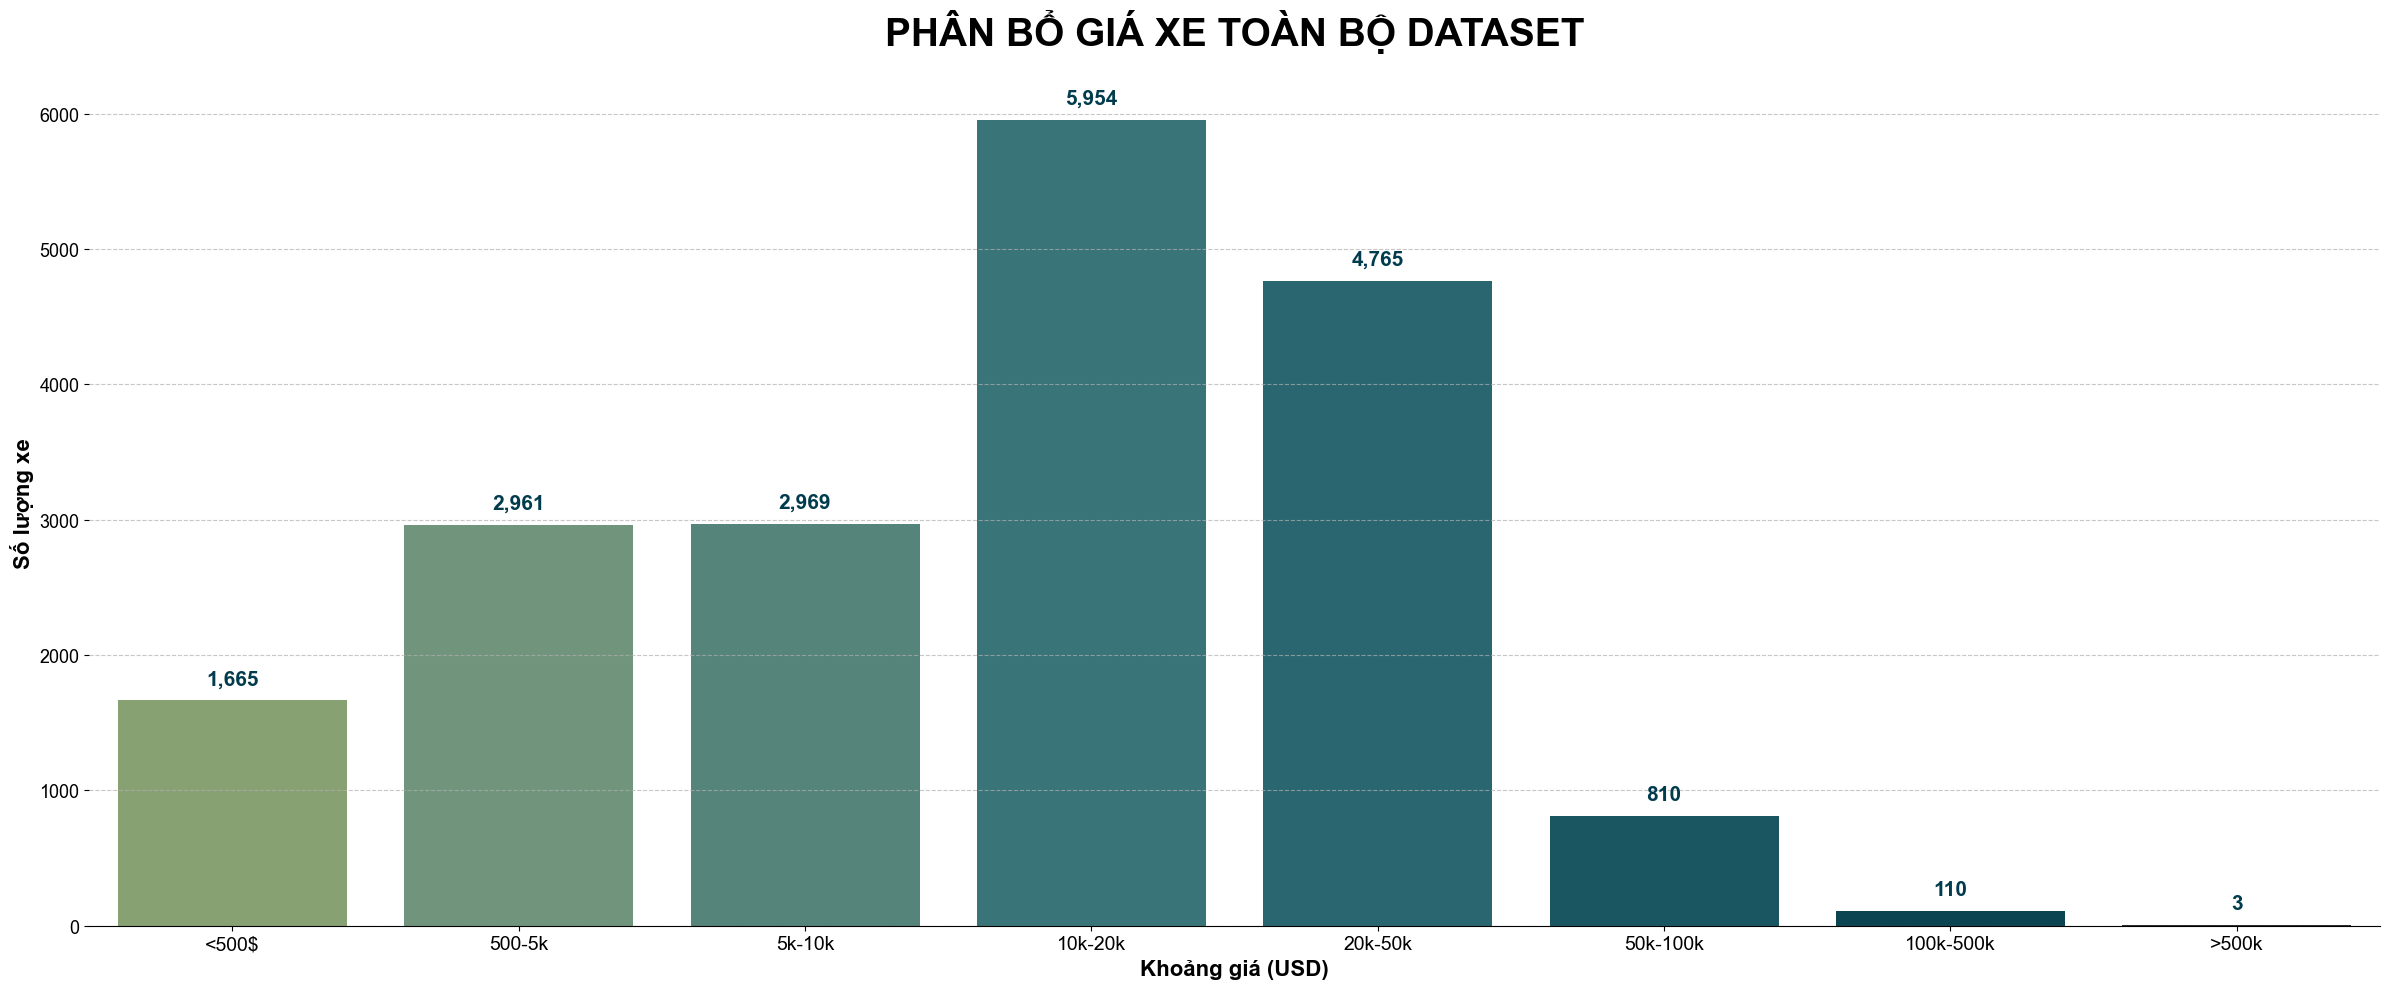

In [8]:
# ── Fix: dùng df_raw, convert Price sang số ──
df_plot = df_raw.copy()
df_plot['Price'] = pd.to_numeric(df_plot['Price'], errors='coerce')
df_plot = df_plot.dropna(subset=['Price'])
# ─────────────────────────────────────────────

import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['Arial', 'Tahoma', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# ==================================================
# CHỈ GIỮ 1 BIỂU ĐỒ TOÀN CẢNH
# ==================================================
fig, ax1 = plt.subplots(figsize=(24, 10))

# ===== 1. TỔNG QUAN =====
bins1 = [0, 500, 5000, 10000, 20000, 50000, 100000, 500000, float('inf')]
labels1 = ['<500$', '500-5k', '5k-10k', '10k-20k', '20k-50k', '50k-100k', '100k-500k', '>500k']

df_plot['Price_Group'] = pd.cut(
    df_plot['Price'],
    bins=bins1,
    labels=labels1,
    include_lowest=True
)

group1 = df_plot['Price_Group'].value_counts().reindex(labels1).fillna(0)

colors1 = ['#87A96B','#6A9B7A','#4D8C7E','#2F7D82','#1E6E7A','#0E5E6D','#004C5E','#2C2C2C']

sns.barplot(
    x=group1.index,
    y=group1.values,
    ax=ax1,
    palette=colors1,
    hue=group1.index,
    legend=False
)

# ===== TITLE =====
ax1.set_title(
    'PHÂN BỔ GIÁ XE TOÀN BỘ DATASET',
    fontsize=28,
    fontweight='bold',
    pad=25
)

# ===== LABEL =====
ax1.set_ylabel(
    'Số lượng xe',
    fontsize=16,
    fontweight='bold'
)

ax1.set_xlabel(
    'Khoảng giá (USD)',
    fontsize=16,
    fontweight='bold'
)

# ===== GRID =====
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)

# ===== XÓA BORDER =====
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

# ===== PHÓNG TO FONT TRỤC =====
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=13)

# ===== HIỆN SỐ LƯỢNG =====
for i, v in enumerate(group1.values):
    if v > 0:
        ax1.text(
            i,
            v + max(group1.values)*0.02,
            f'{int(v):,}',
            ha='center',
            fontweight='bold',
            color='#003C4D',
            fontsize=15
        )

plt.tight_layout()

plt.show()

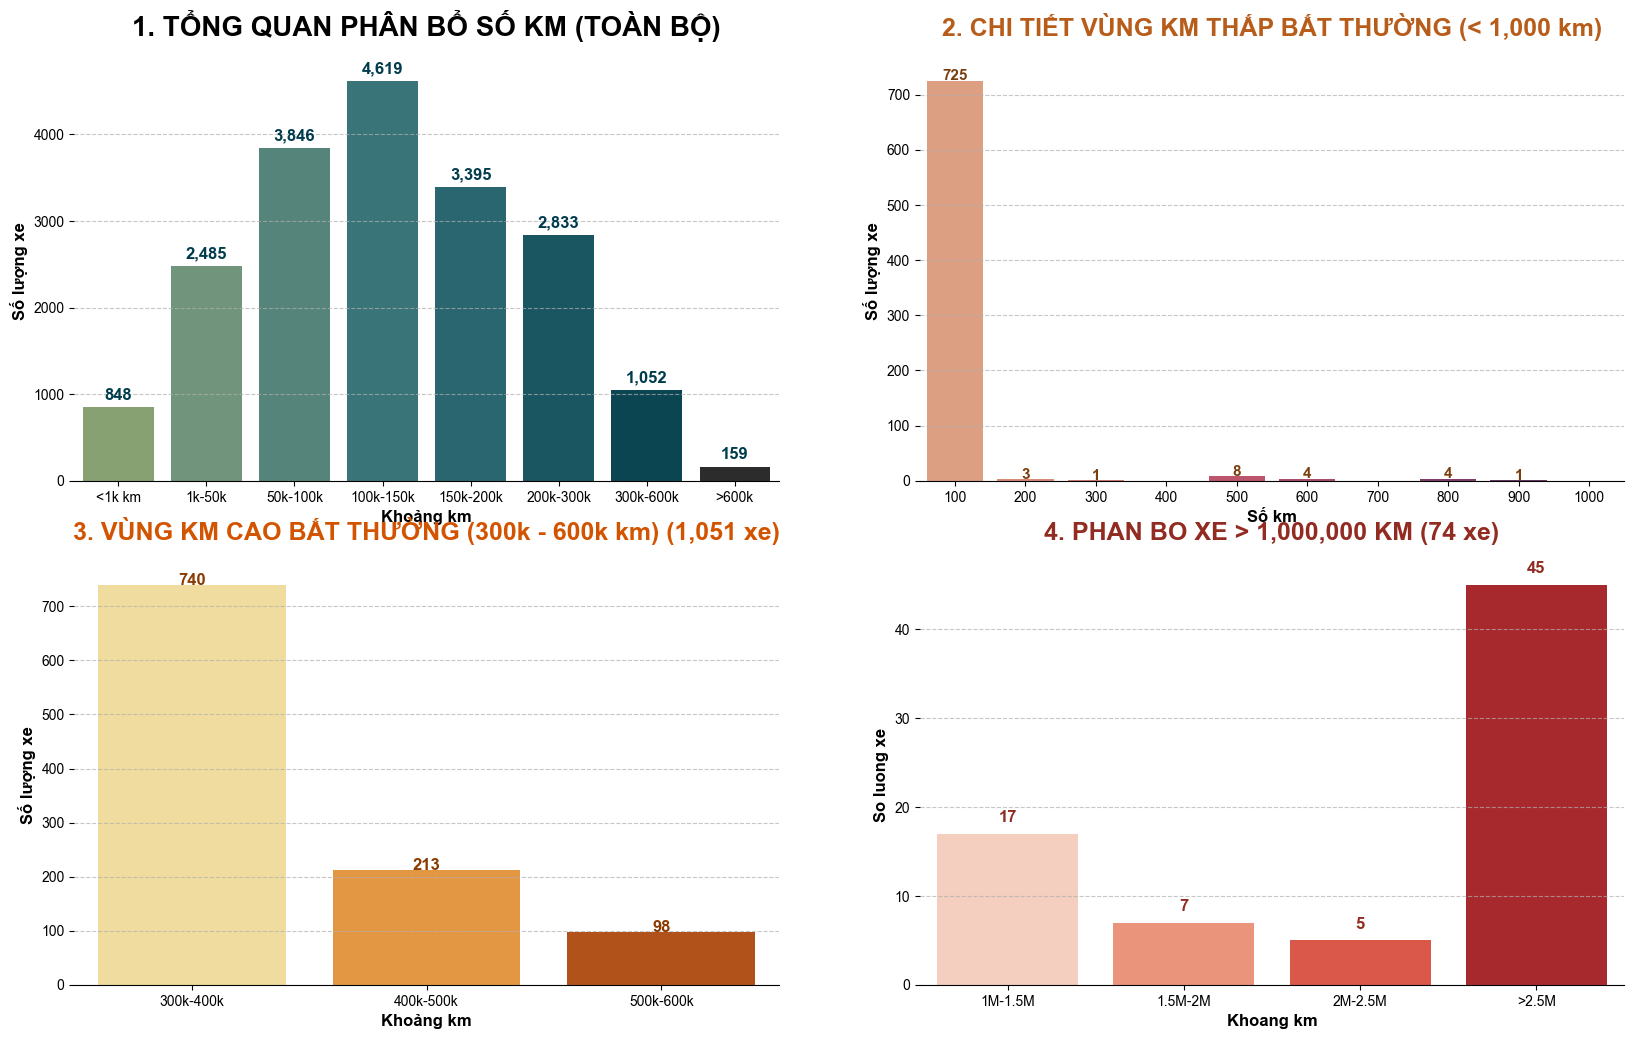

In [9]:
# ── Fix: dùng df_raw, convert Mileage sang số ──
df_plot2 = df_raw.copy()
df_plot2['Mileage'] = df_plot2['Mileage'].astype(str).str.replace(' km', '', regex=False)
df_plot2['Mileage'] = pd.to_numeric(df_plot2['Mileage'], errors='coerce')
df_plot2 = df_plot2.dropna(subset=['Mileage'])
# ───────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

# ===== 1. TỔNG QUAN =====
bins1 = [0, 1000, 50000, 100000, 150000, 200000, 300000, 600000, float('inf')]
labels1 = ['<1k km', '1k-50k', '50k-100k', '100k-150k', '150k-200k', '200k-300k', '300k-600k', '>600k']
df_plot2['Mileage_Group'] = pd.cut(df_plot2['Mileage'], bins=bins1, labels=labels1, include_lowest=True)
group1 = df_plot2['Mileage_Group'].value_counts().reindex(labels1).fillna(0)

ax1 = axes[0, 0]
colors1 = ['#87A96B','#6A9B7A','#4D8C7E','#2F7D82','#1E6E7A','#0E5E6D','#004C5E','#2C2C2C']
sns.barplot(x=group1.index, y=group1.values, ax=ax1, palette=colors1, hue=group1.index, legend=False)
ax1.set_title('1. TỔNG QUAN PHÂN BỔ SỐ KM (TOÀN BỘ)', fontsize=20, fontweight='bold', pad=18)
ax1.set_ylabel('Số lượng xe', fontsize=12, fontweight='bold')
ax1.set_xlabel('Khoảng km', fontsize=12, fontweight='bold')
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False); ax1.spines['left'].set_visible(False)
for i, v in enumerate(group1.values):
    if v > 0:
        ax1.text(i, v + max(group1.values)*0.02, f'{int(v):,}', ha='center', fontweight='bold', color='#003C4D', fontsize=12)

# ===== 2. VÙNG KM THẤP BẤT THƯỜNG (< 1,000 km) =====
df_low = df_plot2[df_plot2['Mileage'] < 1000].copy()
bins2 = list(range(0, 1100, 100))
labels2 = [str(i) for i in range(100, 1100, 100)]
df_low['Mileage_Bin2'] = pd.cut(df_low['Mileage'], bins=bins2, labels=labels2, include_lowest=True)
group2 = df_low['Mileage_Bin2'].value_counts().reindex(labels2).fillna(0)

ax2 = axes[0, 1]
sns.barplot(x=group2.index, y=group2.values, ax=ax2, palette='flare', hue=group2.index, legend=False)
ax2.set_title('2. CHI TIẾT VÙNG KM THẤP BẤT THƯỜNG (< 1,000 km)', fontsize=18, fontweight='bold', color='#B85C1A', pad=18)
ax2.set_xlabel('Số km', fontsize=12, fontweight='bold')
ax2.set_ylabel('Số lượng xe', fontsize=12, fontweight='bold')
ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False); ax2.spines['left'].set_visible(False)
for i, v in enumerate(group2.values):
    if v > 0:
        ax2.text(i, v + 1, f'{int(v):,}', ha='center', fontweight='bold', color='#7A3E0F', fontsize=11)
# ===== 3. VÙNG KM CAO BẤT THƯỜNG (300k - 600k km) =====
df_high = df_plot2[(df_plot2['Mileage'] > 300_000) & (df_plot2['Mileage'] < 600_000)].copy()

bins3 = [300000, 400000, 500000, 600000]
labels3 = ['300k-400k', '400k-500k', '500k-600k']

df_high['Mileage_Bin3'] = pd.cut(
    df_high['Mileage'],
    bins=bins3,
    labels=labels3,
    include_lowest=True
)

group3 = df_high['Mileage_Bin3'].value_counts().reindex(labels3).fillna(0)

ax3 = axes[1, 0]

sns.barplot(
    x=group3.index,
    y=group3.values,
    ax=ax3,
    palette='YlOrBr',
    hue=group3.index,
    legend=False
)

ax3.set_title(
    f'3. VÙNG KM CAO BẤT THƯỜNG (300k - 600k km) ({len(df_high):,} xe)',
    fontsize=18,
    fontweight='bold',
    color='#D35400',
    pad=18
)

ax3.set_xlabel('Khoảng km', fontsize=12, fontweight='bold')
ax3.set_ylabel('Số lượng xe', fontsize=12, fontweight='bold')

ax3.yaxis.grid(True, linestyle='--', alpha=0.7)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

for i, v in enumerate(group3.values):
    if v > 0:
        ax3.text(
            i,
            v + 0.3,
            f'{int(v):,}',
            ha='center',
            fontweight='bold',
            color='#8B3A00',
            fontsize=12
        )
# ===== 4. PHÂN BỔ XE > 1M KM =====
df_1m = df_plot2[df_plot2['Mileage'] > 1_000_000].copy()
bins4 = [1000000, 1500000, 2000000, 2500000, float('inf')]
labels4 = ['1M-1.5M', '1.5M-2M', '2M-2.5M', '>2.5M']
df_1m['Mileage_Bin4'] = pd.cut(df_1m['Mileage'], bins=bins4, labels=labels4, include_lowest=True)
group4 = df_1m['Mileage_Bin4'].value_counts().reindex(labels4).fillna(0)

ax4 = axes[1, 1]
sns.barplot(x=group4.index, y=group4.values, ax=ax4, palette='Reds', hue=group4.index, legend=False)
ax4.set_title(f'4. PHAN BO XE > 1,000,000 KM ({len(df_1m):,} xe)', fontsize=18, fontweight='bold', color='#922B21', pad=18)
ax4.set_xlabel('Khoang km', fontsize=12, fontweight='bold')
ax4.set_ylabel('So luong xe', fontsize=12, fontweight='bold')
ax4.yaxis.grid(True, linestyle='--', alpha=0.7)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False); ax4.spines['left'].set_visible(False)
for i, v in enumerate(group4.values):
    if v > 0:
        ax4.text(i, v + max(group4.values) * 0.03, f'{int(v):,}', ha='center', fontweight='bold', color='#922B21', fontsize=12)


XỬ LÍ OUTLIER

In [10]:
initial_rows = df.shape[0]

df_final = df[
    (df['Price']   >= 5_000)   & (df['Price']   <= 50_000) &
    (df['Mileage'] >= 1_000)   & (df['Mileage'] <= 400_000)
]

final_rows = df_final.shape[0]
print(f"✅ Da loc xong ngoai lai!")
print(f"👉 So dong bi loai: {initial_rows - final_rows:,} dong")
print(f"📉 Gia xe: {df_final['Price'].min():,.0f}$ → {df_final['Price'].max():,.0f}$")
print(f"📏 So km: {df_final['Mileage'].min():,.0f} km → {df_final['Mileage'].max():,.0f} km")
print(f"📊 Con lai: {final_rows:,} dong")


✅ Da loc xong ngoai lai!
👉 So dong bi loai: 6,266 dong
📉 Gia xe: 5,000$ → 49,889$
📏 So km: 1,000 km → 400,000 km
📊 Con lai: 12,971 dong


In [11]:
# Lưu phiên bản đã làm sạch đẹp đẽ thành một bảng mới để bạn số 2 lấy ra dùng
df_final.to_sql('Cars_Cleaned', con=engine, if_exists='replace', index=False)

print("🚀 HOÀN TẤT! Dữ liệu sạch đã nằm trong bảng 'Cars2_Cleaned'")

🚀 HOÀN TẤT! Dữ liệu sạch đã nằm trong bảng 'Cars2_Cleaned'


TẠO BẢN ĐỒ HÃNG XE-DÒNG XE VÀ CHIA TẬP DỮ LIỆU

In [12]:
# 1. Xử lý phông chữ rác trước (Đổi các ký tự lỗi ??? hoặc tiếng Gruzia thành 'Other')
for col in ['Manufacturer', 'Model']:
    df_final[col] = df_final[col].apply(lambda x: 'Other' if '?' in str(x) or 'სხვა' in str(x) else x)

encoding_dict = {}

# 2. Tạo Bản đồ Hãng xe -> Dòng xe trên toàn bộ dữ liệu (vì không chứa biến mục tiêu Price, không lo leakage)
mfg_model_mapping = df_final.groupby('Manufacturer')['Model'].unique().apply(list).to_dict()
encoding_dict['mfg_model_mapping'] = mfg_model_mapping

# 3. Chia tập dữ liệu thành 80% Train và 20% Test TRƯỚC KHI MÃ HÓA để tránh Data Leakage
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_final, test_size=0.2, random_state=42)

print("✅ Đã chuẩn bị dữ liệu và chia tập Train/Test thành công!")


✅ Đã chuẩn bị dữ liệu và chia tập Train/Test thành công!


MÃ HÓA DỮ LIỆU

In [13]:

# 1. Đảm bảo đủ 8 cột thuộc tính phân loại cần mã hóa
cat_features = ['Manufacturer', 'Model', 'Category', 'Fuel type', 
                'Gear box type', 'Drive wheels', 'Color', 'Leather interior']

# 2. Tính trung bình giá xe trên TẬP TRAIN (Global Mean)
global_mean = train_df['Price'].mean()
encoding_dict['global_mean'] = global_mean

# 3. Tính toán Target Encoding (Mean Encoding) CHỈ dựa trên dữ liệu tập Train
for col in cat_features:
    # Tính toán mean_map trên train_df
    mean_map = train_df.groupby(col)['Price'].mean().to_dict()
    encoding_dict[col] = mean_map
    
    # Ánh xạ lên cả tập Train và tập Test (fillna bằng global_mean của tập Train)
    train_df[col] = train_df[col].map(mean_map).fillna(global_mean)
    test_df[col] = test_df[col].map(mean_map).fillna(global_mean)

# 4. Xuất từ điển mã hóa ra file target_encoders.pkl
with open('target_encoders.pkl', 'wb') as f:
    pickle.dump(encoding_dict, f)

# 5. Xuất tập dữ liệu Train/Test đã được mã hóa ra file CSV
train_df.to_csv('car_price_train_clean.csv', index=False)
test_df.to_csv('car_price_test_clean.csv', index=False)

print("✅ Đã mã hóa dữ liệu tránh Leakage và lưu từ điển thành công!")
print(f"📊 Tập Train: {train_df.shape[0]} dòng (đã lưu vào 'car_price_train_clean.csv')")
print(f"📊 Tập Test: {test_df.shape[0]} dòng (đã lưu vào 'car_price_test_clean.csv')")


✅ Đã mã hóa dữ liệu tránh Leakage và lưu từ điển thành công!
📊 Tập Train: 10376 dòng (đã lưu vào 'car_price_train_clean.csv')
📊 Tập Test: 2595 dòng (đã lưu vào 'car_price_test_clean.csv')


UYÊN

HUẤN LUYỆN MÔ HÌNH

In [14]:

# 1. Tách X (tính năng) và y (giá xe) từ tập Train và Test
X_train = train_df.drop(['Price', 'ID'], axis=1)
y_train = train_df['Price']

X_test = test_df.drop(['Price', 'ID'], axis=1)
y_test = test_df['Price']

# 2. Khởi tạo mô hình Random Forest
# n_estimators=100: dùng 100 cây quyết định để bỏ phiếu
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 3. Cho máy học (Training)
model.fit(X_train, y_train)
with open('best_rf_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("✅ Đã huấn luyện và lưu mô hình Random Forest vào file 'best_rf_model.pkl'!")



✅ Đã huấn luyện và lưu mô hình Random Forest vào file 'best_rf_model.pkl'!


ĐÁNH GIÁ MÔ HÌNH

In [15]:
# ==========================================
# ĐÁNH GIÁ RANDOM FOREST
# ==========================================

y_pred_rf = model.predict(X_test)

rf_mae   = mean_absolute_error(y_test, y_pred_rf)
rf_mse   = mean_squared_error(y_test, y_pred_rf)
rf_rmse  = np.sqrt(rf_mse)
rf_r2    = r2_score(y_test, y_pred_rf)
rf_medae = median_absolute_error(y_test, y_pred_rf)
rf_mape  = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

n = len(y_test)
p = X_test.shape[1]

rf_adj_r2 = 1 - (1 - rf_r2) * (n - 1) / (n - p - 1)

print("📊 DANH GIA MO HINH RANDOM FOREST")
print("=" * 55)

print(f"MAE (Mean Absolute Error)        : {rf_mae:,.2f} $")
print(f"MSE (Mean Squared Error)         : {rf_mse:,.2f}")
print(f"RMSE (Root Mean Squared Error)   : {rf_rmse:,.2f} $")
print(f"Median AE (Median Absolute Error): {rf_medae:,.2f} $")
print(f"MAPE (Mean Absolute Percentage Error): {rf_mape:.2f} %")
print(f"R2 Score (Do giai thich du lieu) : {rf_r2:.4f}")
print(f"Adjusted R2                      : {rf_adj_r2:.4f}")

print("=" * 55)

📊 DANH GIA MO HINH RANDOM FOREST
MAE (Mean Absolute Error)        : 3,261.45 $
MSE (Mean Squared Error)         : 27,731,528.19
RMSE (Root Mean Squared Error)   : 5,266.07 $
Median AE (Median Absolute Error): 1,915.13 $
MAPE (Mean Absolute Percentage Error): 20.24 %
R2 Score (Do giai thich du lieu) : 0.7565
Adjusted R2                      : 0.7551


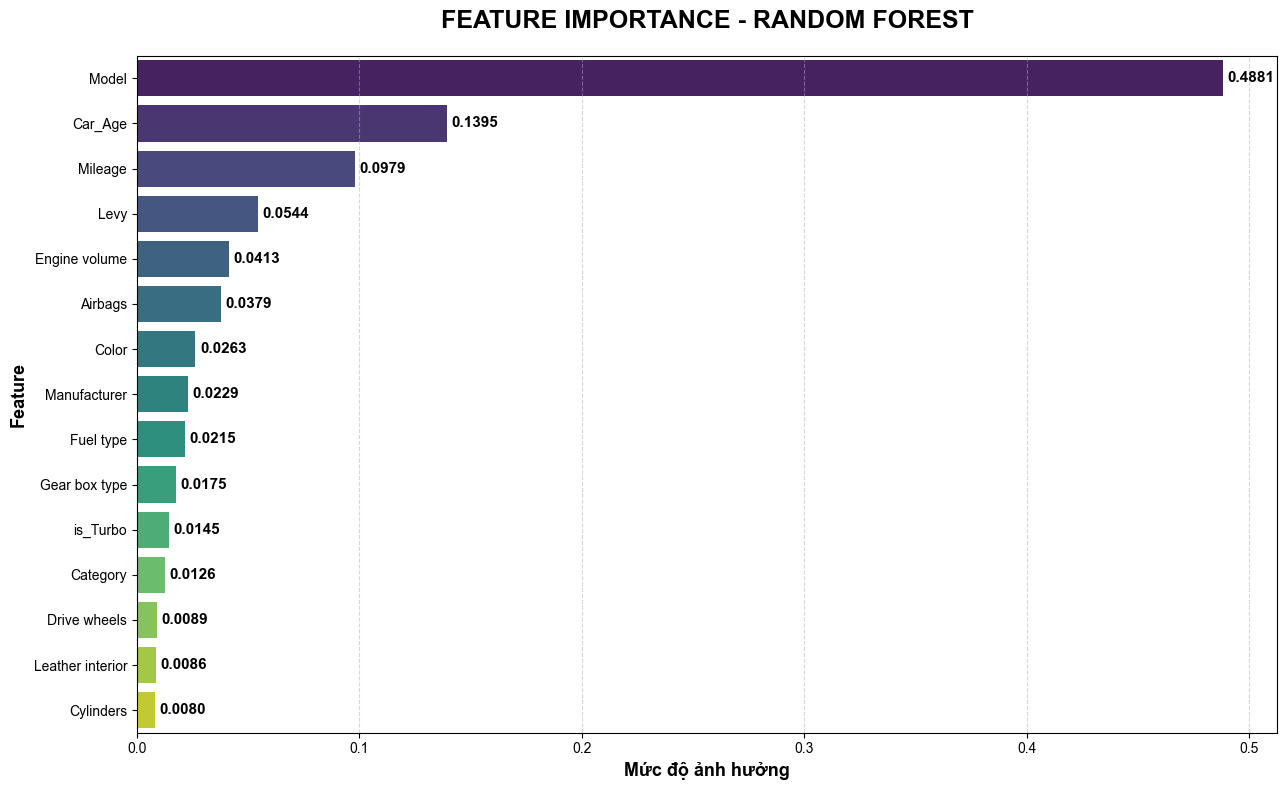

In [16]:

# ==============================
# FEATURE IMPORTANCE RANDOM FOREST
# ==============================

feature_cols = [col for col in train_df.drop('Price', axis=1).columns if col != 'ID']

importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances[:len(feature_cols)]
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# ==============================
# VẼ BIỂU ĐỒ
# ==============================

plt.figure(figsize=(13, 8))

ax = sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature',
    hue='Feature',
    palette='viridis',
    legend=False
)

# HIỆN SỐ TRÊN TỪNG THANH
for i, value in enumerate(importance_df['Importance']):
    ax.text(
        value + 0.002,      # vị trí ngang
        i,                  # vị trí dọc
        f"{value:.4f}",    # format số
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'FEATURE IMPORTANCE - RANDOM FOREST',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel(
    'Mức độ ảnh hưởng',
    fontsize=13,
    fontweight='bold'
)

plt.ylabel(
    'Feature',
    fontsize=13,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

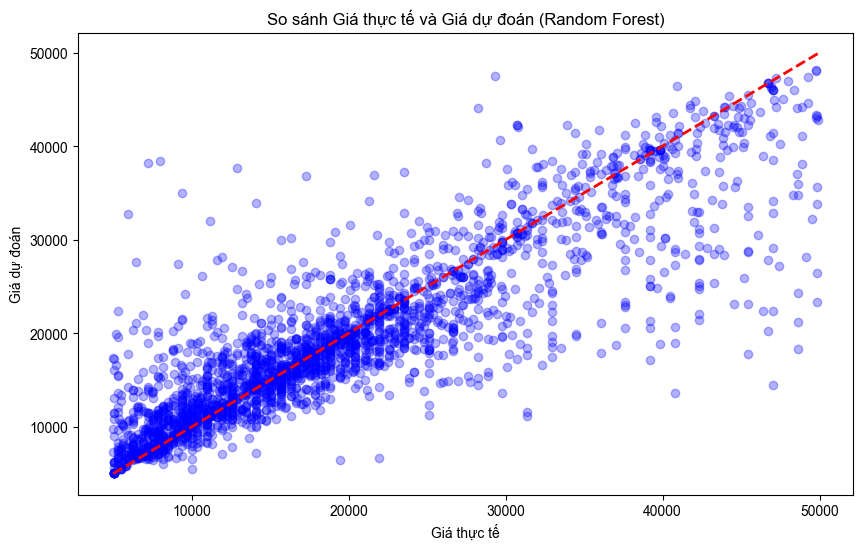

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá thực tế')
plt.ylabel('Giá dự đoán')
plt.title('So sánh Giá thực tế và Giá dự đoán (Random Forest)')
plt.show()


In [18]:


# 1. Khởi tạo mô hình XGBoost
# Tương tự như RandomForest, XGBoost cũng dùng random_state=42 để cố định kết quả
xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42,
    objective='reg:squarederror'
)

# 2. Huấn luyện (Training)
print("Đang huấn luyện mô hình XGBoost...")
xgb_model.fit(X_train, y_train)

# 3. Lưu mô hình
with open('best_xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✅ Đã huấn luyện và lưu mô hình XGBoost vào file 'best_xgb_model.pkl'!")

# ==========================================
# ĐÁNH GIÁ XGBOOST
# ==========================================

y_pred_xgb = xgb_model.predict(X_test)

xgb_mae   = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse   = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse  = np.sqrt(xgb_mse)
xgb_r2    = r2_score(y_test, y_pred_xgb)
xgb_medae = median_absolute_error(y_test, y_pred_xgb)
xgb_mape  = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

n = len(y_test)
p = X_test.shape[1]

xgb_adj_r2 = 1 - (1 - xgb_r2) * (n - 1) / (n - p - 1)

print("📊 DANH GIA MO HINH XGBOOST")
print("=" * 55)

print(f"MAE (Mean Absolute Error)        : {xgb_mae:,.2f} $")
print(f"MSE (Mean Squared Error)         : {xgb_mse:,.2f}")
print(f"RMSE (Root Mean Squared Error)   : {xgb_rmse:,.2f} $")
print(f"Median AE (Median Absolute Error): {xgb_medae:,.2f} $")
print(f"MAPE (Mean Absolute Percentage Error): {xgb_mape:.2f} %")
print(f"R2 Score (Do giai thich du lieu) : {xgb_r2:.4f}")
print(f"Adjusted R2                      : {xgb_adj_r2:.4f}")

print("=" * 55)

Đang huấn luyện mô hình XGBoost...
✅ Đã huấn luyện và lưu mô hình XGBoost vào file 'best_xgb_model.pkl'!
📊 DANH GIA MO HINH XGBOOST
MAE (Mean Absolute Error)        : 3,709.55 $
MSE (Mean Squared Error)         : 29,743,306.00
RMSE (Root Mean Squared Error)   : 5,453.74 $
Median AE (Median Absolute Error): 2,417.76 $
MAPE (Mean Absolute Percentage Error): 23.68 %
R2 Score (Do giai thich du lieu) : 0.7389
Adjusted R2                      : 0.7373


CODE THƯ VIỆN

In [19]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTree:
    # Thêm max_thresholds để giới hạn số lần duyệt cắt nhánh
    def __init__(self, min_samples_split=2, max_depth=100, n_features=None, max_thresholds=15):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.max_thresholds = max_thresholds 
        self.root = None

    def fit(self, X, y):

        if not self.n_features:
            self.n_features = max(1, X.shape[1] // 3)
        self.root = self._grow_tree(X, y)

    def _grow_tree(self, X, y, depth=0):
        n_samples, n_feats = X.shape

        # Kiểm tra điều kiện dừng
        if depth >= self.max_depth or n_samples < self.min_samples_split or self._variance(y) == 0:
            return Node(value=np.mean(y))
        
        # Lựa chọn ngẫu nhiên n_features 
        feat_idxs = np.random.choice(n_feats, self.n_features, replace=False)

        # Tìm cách phân chia tốt nhất
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)

        # Nếu không tìm ra cách phân chia tốt
        if best_feature is None:
            return Node(value=np.mean(y))

        # Tạo nút con (đệ quy)
        left_idxs, right_idxs = self._split(X[:, best_feature], best_thresh)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return Node(value=np.mean(y))

        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth + 1)

        return Node(best_feature, best_thresh, left, right)

    def _best_split(self, X, y, feat_idxs):
        best_gain = -float("inf")
        split_idx, split_threshold = None, None

        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            
            # TỐI ƯU 1: Cắt giảm số lượng thresholds nếu quá nhiều 
            if len(thresholds) > self.max_thresholds:
                thresholds = np.percentile(X_column, np.linspace(5, 95, self.max_thresholds))

            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = threshold

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
                # Phân chia dữ liệu
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return -float("inf")
        
        # Sử dụng MSE cho hồi quy
        n = len(y)
        var_parent = self._variance(y)
        var_left = self._variance(y[left_idxs])
        var_right = self._variance(y[right_idxs])

        # Tính toán IG (giảm phương sai)
        gain = var_parent - (len(left_idxs) / n * var_left + len(right_idxs) / n * var_right)
        return gain

    def _variance(self, y):
        # Tối ưu nhỏ: Tránh cảnh báo khi mảng rỗng
        return np.var(y) if len(y) > 0 else 0

    def _split(self, X_column, split_thresh):
        # TỐI ƯU 2: Dùng np.where thay cho np.argwhere.flatten() 
        left_idxs = np.where(X_column <= split_thresh)[0]
        right_idxs = np.where(X_column > split_thresh)[0]
        return left_idxs, right_idxs

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

class RandomForest:

    def __init__(self, n_trees=100, min_samples_split=2, max_depth=100, n_features=None):

        self.n_trees = n_trees
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.trees = []

    def fit(self, X, y):

        self.trees = []

        for i in range(self.n_trees):

            X_sample, y_sample = self._bootstrap_sample(X, y, i)

            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features
            )

            tree.fit(X_sample, y_sample)

            self.trees.append(tree)

            if (i + 1) % 10 == 0:
                print(f"  [+] Đã train {i + 1}/{self.n_trees} cây")

    def _bootstrap_sample(self, X, y, i):

        X_sample, y_sample = resample(
            X,
            y,
            replace=True,
            random_state=42 + i
        )

        return X_sample, y_sample

    def predict(self, X):

        predictions = np.array([tree.predict(X) for tree in self.trees])

        y_pred = np.mean(predictions, axis=0)

        return y_pred

if __name__ == "__main__":
    print("Đang load data...")
    train = pd.read_csv("car_price_train_clean.csv")
    feature_cols = [c for c in train.columns if c != "Price"]
    X_train = train[feature_cols].values
    y_train = train["Price"].values

    print(f"Dữ liệu huấn luyện: {X_train.shape}")

    # Khởi tạo và Train 
    rf = RandomForest(n_trees=100, max_depth=10, min_samples_split=5)
    rf.fit(X_train, y_train)

    # LƯU MÔ HÌNH ĐÃ TRAIN
    with open('random_forest_model.pkl', 'wb') as f:
        pickle.dump(rf, f)
    
    print("\n Đã Train xong và lưu mô hình thành công!")

Đang load data...
Dữ liệu huấn luyện: (10376, 16)
  [+] Đã train 10/100 cây
  [+] Đã train 20/100 cây
  [+] Đã train 30/100 cây
  [+] Đã train 40/100 cây
  [+] Đã train 50/100 cây
  [+] Đã train 60/100 cây
  [+] Đã train 70/100 cây
  [+] Đã train 80/100 cây
  [+] Đã train 90/100 cây
  [+] Đã train 100/100 cây

 Đã Train xong và lưu mô hình thành công!


ĐÁNH GIÁ CÁC CHỈ SỐ

In [20]:

# 1. Đọc dữ liệu tập Test đã làm sạch
test_data = pd.read_csv("car_price_test_clean.csv")
feature_cols = [c for c in test_data.columns if c != "Price"]
X_test = test_data[feature_cols].values
y_test = test_data["Price"].values

# 2. Tải mô hình tự viết đã train và lưu thành công
with open('random_forest_model.pkl', 'rb') as f:
    model_custom = pickle.load(f)

# 3. Dự đoán giá xe trên tập Test
y_pred = model_custom.predict(X_test)

# 4. Tính toán các chỉ số đánh giá tương tự mô hình của sklearn
custom_mae   = mean_absolute_error(y_test, y_pred)
custom_mse   = mean_squared_error(y_test, y_pred)
custom_rmse  = np.sqrt(custom_mse)
custom_r2    = r2_score(y_test, y_pred)
custom_medae = median_absolute_error(y_test, y_pred)
custom_mape  = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
n     = len(y_test)
p     = X_test.shape[1]
custom_adj_r2 = 1 - (1 - custom_r2) * (n - 1) / (n - p - 1)

# 5. In kết quả đánh giá chi tiết
print("📊 ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST TỰ VIẾT (CUSTOM)")
print("=" * 50)
print(f"  MAE          : {custom_mae:,.2f} $")
print(f"  MSE          : {custom_mse:,.2f}")
print(f"  RMSE         : {custom_rmse:,.2f} $")
print(f"  Median AE    : {custom_medae:,.2f} $")
print(f"  MAPE         : {custom_mape:.2f} %")
print(f"  R2 Score     : {custom_r2:.4f}")
print(f"  Adjusted R2  : {custom_adj_r2:.4f}")


📊 ĐÁNH GIÁ MÔ HÌNH RANDOM FOREST TỰ VIẾT (CUSTOM)
  MAE          : 3,998.54 $
  MSE          : 33,114,558.92
  RMSE         : 5,754.53 $
  Median AE    : 2,704.34 $
  MAPE         : 26.31 %
  R2 Score     : 0.7093
  Adjusted R2  : 0.7075


📊 BẢNG SO SÁNH 3 MÔ HÌNH


,Random Forest,XGBoost,RF Code Tay
MAE,3261.451124,3709.546875,3998.539550
RMSE,5266.073318,5453.742385,5754.525082
MAPE,20.238867,23.684238,26.311169
R2,0.756523,0.738860,0.709262


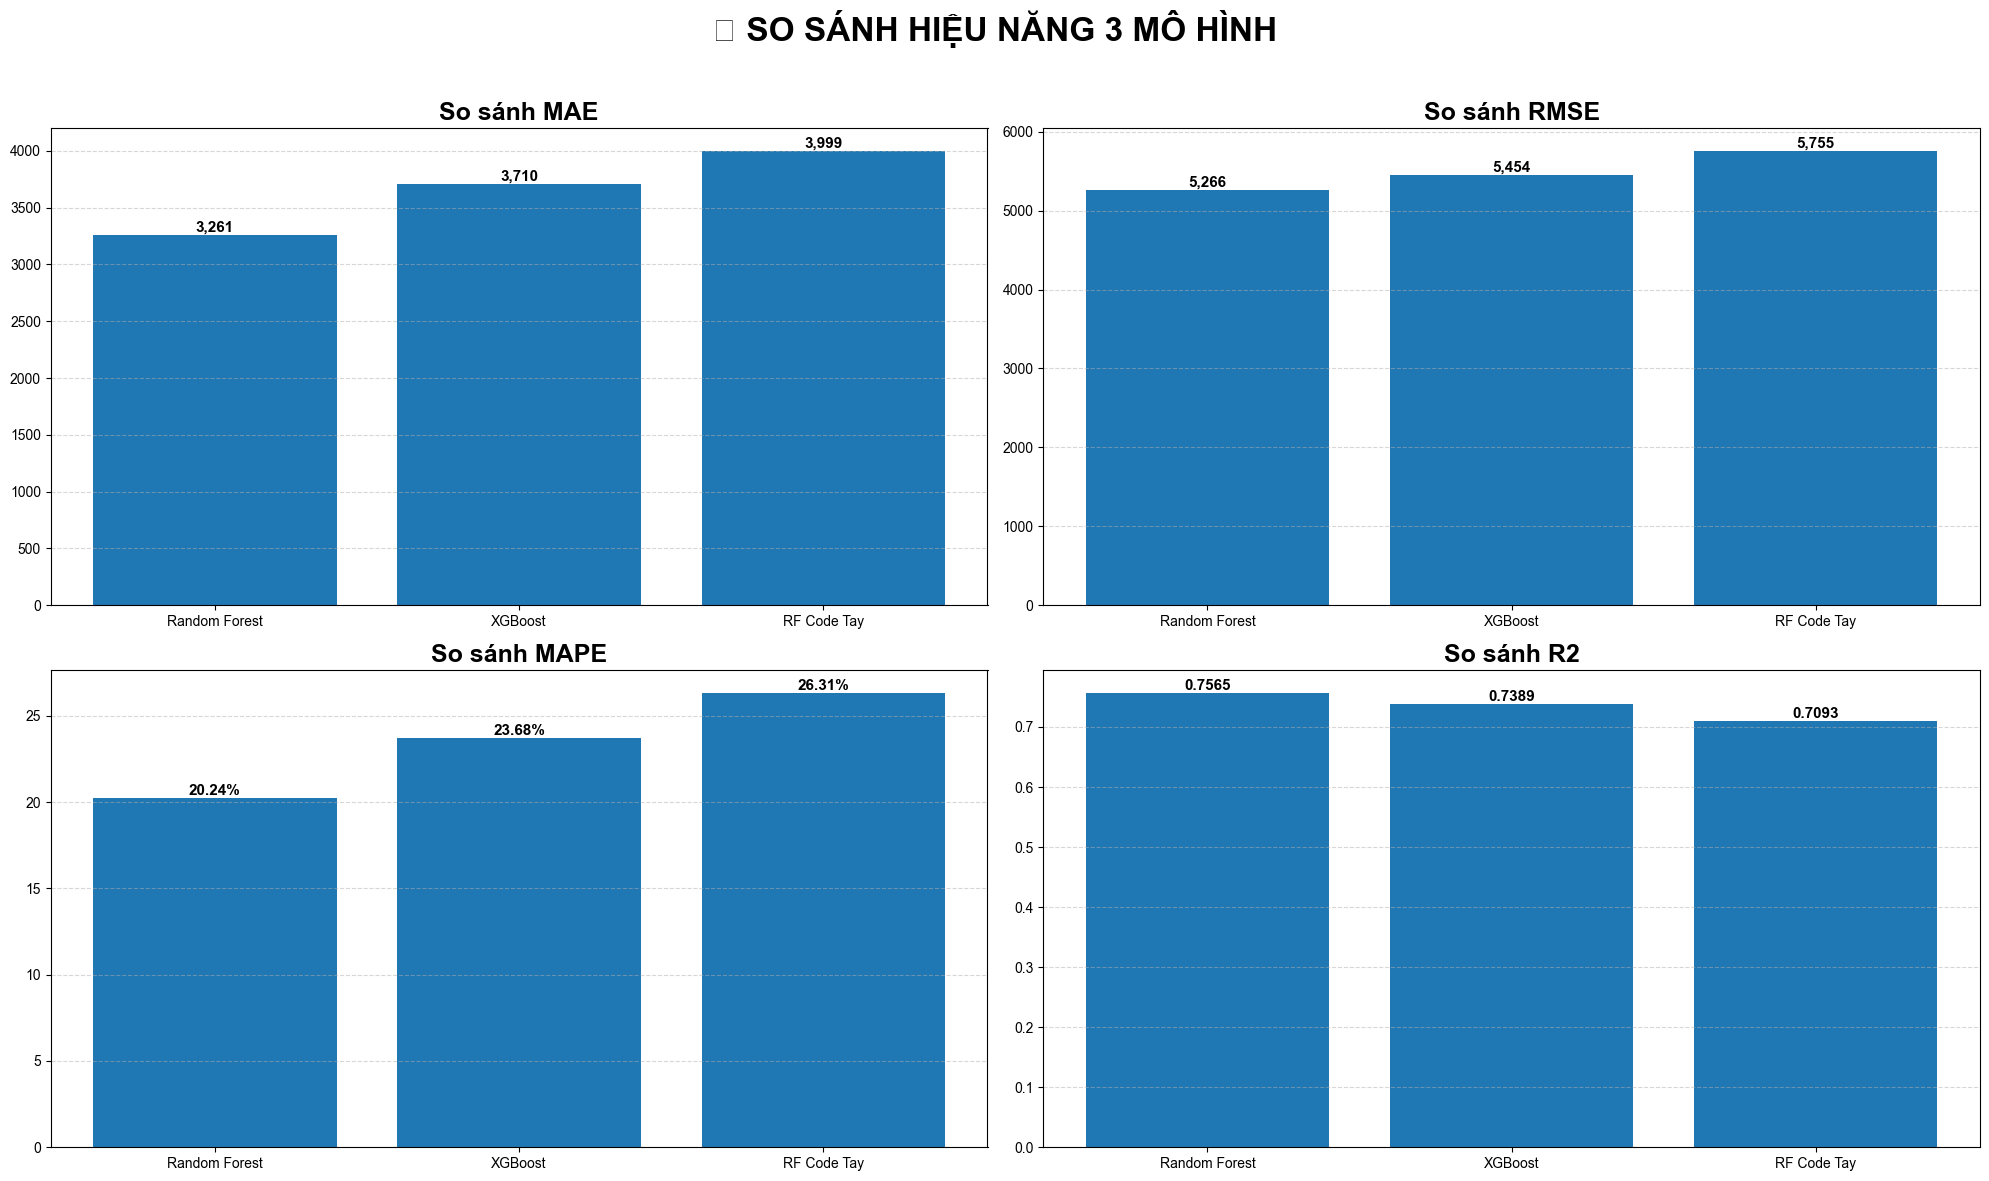

In [21]:
# ==========================================
# BIỂU ĐỒ SO SÁNH 3 MÔ HÌNH
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

compare_df = pd.DataFrame({
    'Random Forest': [
        rf_mae, rf_rmse, rf_mape, rf_r2
    ],
    
    'XGBoost': [
        xgb_mae, xgb_rmse, xgb_mape, xgb_r2
    ],
    
    'RF Code Tay': [
        custom_mae, custom_rmse, custom_mape, custom_r2
    ]

}, index=['MAE', 'RMSE', 'MAPE', 'R2'])

print("📊 BẢNG SO SÁNH 3 MÔ HÌNH")
display(compare_df)

# ==========================================
# VẼ BIỂU ĐỒ
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

metrics = ['MAE', 'RMSE', 'MAPE', 'R2']

for ax, metric in zip(axes.flatten(), metrics):

    values = compare_df.loc[metric]

    bars = ax.bar(
        values.index,
        values.values
    )

    ax.set_title(
        f'So sánh {metric}',
        fontsize=18,
        fontweight='bold'
    )

    ax.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:

        height = bar.get_height()

        if metric == 'R2':
            label = f'{height:.4f}'
        elif metric == 'MAPE':
            label = f'{height:.2f}%'
        else:
            label = f'{height:,.0f}'

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            label,
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold'
        )

plt.suptitle(
    '📈 SO SÁNH HIỆU NĂNG 3 MÔ HÌNH',
    fontsize=24,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()